Mohammad Mohannad Al Kawadri 

# CA2 - Supervised machine learning classification pipeline - applied to medical data

### Important information

- Do __not__ use scikit-learn (`sklearn`) or any other high-level machine learning library for this CA
- Explain your code and reasoning in markdown cells or code comments
- Label all graphs and charts if applicable
- If you use code from the internet, make sure to reference it and explain it in your own words
- If you use additional function arguments, make sure to explain them in your own words
- Use the classes `Perceptron`, `Adaline` and `Logistic Regression` from the library `mlxtend` as classifiers (`from mlxtend.classifier import Perceptron, Adaline, LogisticRegression`). _Always_ use the argument `minibatches=1` when instantiating an `Adaline` or `LogisticRegression` object. This makes the model use the gradient descent algorithm for training. Always use the `random_seed=42` argument when instantiating the classifiers. This will make your results reproducible.
- You can use any plotting library you want (e.g. `matplotlib`, `seaborn`, `plotly`, etc.)
- Use explanatory variable names (e.g. `X_train` and `X_train_scaled` for the training data before and after scaling, respectively)
- The dataset is provided in the file `fetal_health.csv` in the `assets` folder

### Additional clues

- Use the `pandas` library for initial data inspection and preprocessing
- Before training the classifiers, convert the data to raw `numpy` arrays
- For Part IV, you are aiming to create a plot that looks similar to this:
<img src="./assets/example_output.png" width="300">

### Additional information

- Feel free to create additional code or markdown cells if you think it will help you explain your reasoning or structure your code (you don't have to).


## Part I: Data loading and data exploration

### Import necessary libraries/modules:

In [1]:
# Insert your code below
# ======================
from mlxtend.classifier import Perceptron, Adaline, LogisticRegression
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings

### Loading and exploring data

1. Load the dataset `fetal_health.csv` with `pandas`. Use the first column as the row index.
2. Check for missing data, report on your finding and remove samples with missing data, if you find any.
3. Display the raw data with appropriate plots/outputs and inspect it. Describe the distributions of the values of feature `"baseline value"`, `"accelerations"`, and the target variable `"fetal_health"`.
4. Will it be beneficial to scale the data? Why or why not?
5. Is the data linearly separable using a combination of any two pairs of features? Can we expect an accuracy close to 100% from a linear classifier?

In [2]:
# Insert your code below
# ======================
#exercise 1.
df_health=pd.read_csv('assets/fetal_health.csv', index_col=0)

In [3]:
#exercise 2.
df_health.isnull().sum()

baseline value                                            0
accelerations                                             0
prolongued_decelerations                                  0
abnormal_short_term_variability                           0
mean_value_of_short_term_variability                      0
percentage_of_time_with_abnormal_long_term_variability    0
histogram_mean                                            0
histogram_variance                                        0
fetal_health                                              0
dtype: int64

In [4]:
# We see that there is no missing data so we dont need to remove anything

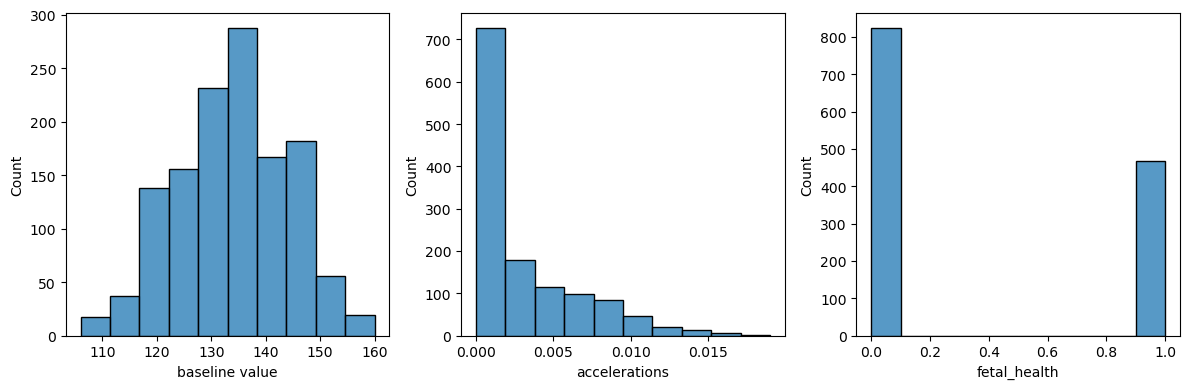

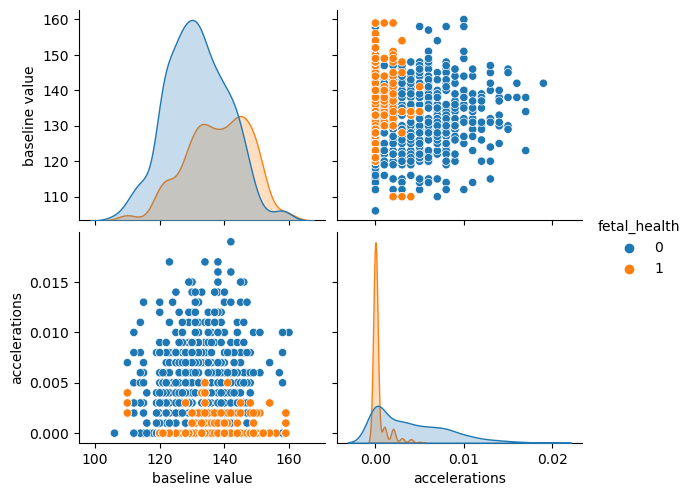

In [5]:
#exercise 3.
fig, axes = plt.subplots(1,3,figsize=(12,4))
sns.histplot(data=df_health["baseline value"], ax=axes[0], bins=10)
sns.histplot(data=df_health["accelerations"], ax=axes[1], bins=10)
sns.histplot(data=df_health["fetal_health"], ax=axes[2], bins=10)
plt.tight_layout()
plt.show()
#exercise 4.
#for baseline value doesn't need for data scaling since 
#the distribution is roughly normal and the range not very wide
#for accelerations scaling might be beneficial 
#due to skewness and clustering of values near 0
#for fetal healt cannot be scaled 
#because of the purpose of feeding it into an alogrithm
warnings.filterwarnings \
('ignore', message='The figure layout has changed to tight')
#i used the warning command because the saeborn is applying a tight layout 
#to the figures which he does automatically, i am just
#using this command to just ignore it just 
#to make the figures more tidy and clear
smalldf_health = df_health\
[['baseline value', 'accelerations', 'fetal_health']]
sns.pairplot(smalldf_health, hue="fetal_health", height=2.5, aspect=1.2)
plt.show()
#exercise 5.
#From the plot that we see, it seems difficult 
#for the data to be linearly separable, 
#cause the data is very close to each other
#which will make the classifiers not so accurat

## Part II: Train/Test Split

Divide your dataset into training and testing subsets. Follow these steps to create the split:

1. **Divide the dataset into two data sets, each data set only contains samples of either class 0 or class 1:**
- Create a DataFrame `df_0` containing all data with `"fetal_health"` equal to 0.
- Create a DataFrame `df_1` containing all data with `"fetal_health"` equal to 1.

2. **Split into training and test set by randomly sampling entries from the data frames:**
- Create a DataFrame `df_0_train` containing by sampling `75%` of the entries from `df_0` (use the `sample` method of the data frame, fix the `random_state` to `42`).
- Create a DataFrame `df_1_train` using the same approach with `df_1`.
- Create a DataFrame `df_0_test` containing the remaining entries of `df_0` (use `df_0.drop(df_0_train.index)` to drop all entries except the previously extracted ones).
- Create a DataFrame `df_1_test` using the same approach with `df_1`.

3. **Merge the datasets split by classes back together:**
- Create a DataFrame `df_train` containing all entries from `df_0_train` and `df_1_train`. (Hint: use the `concat` method you know from CA1)
- Create a DataFrame `df_test` containing all entries from the two test sets.

4. **Create the following data frames from these splits:**
- `X_train`: Contains all columns of `df_train` except for the target feature `"fetal_health"`
- `X_test`: Contains all columns of `df_test` except for the target feature `"fetal_health"`
- `y_train`: Contains only the target feature `"fetal_health"` for all samples in the training set
- `y_test`: Contains only the target feature `"fetal_health"` for all samples in the test set

5. **Check that your sets have the expected sizes/shape by printing number of rows and colums ("shape") of the data sets.**
- (Sanity check: there should be 8 features, almost 1000 samples in the training set and slightly more than 300 samples in the test set.)


6. **Explain the purpose of this slightly complicated procedure. Why did we first split into the two classes? Why did we then split into a training and a testing set?**


7. **What is the share (in percent) of samples with class 0 label in test and training set, and in the intial data set?**



In [6]:
# Insert your code below
# ======================
#exercise 1.
df_0 = df_health[df_health["fetal_health"] == 0]
df_1 = df_health[df_health["fetal_health"] == 1]
#exercise 2.
df_0_train = df_0.sample(frac=0.75, random_state=42)
df_0_test = df_0.drop(df_0_train.index)
df_1_train = df_1.sample(frac=0.75, random_state=42)
df_1_test = df_1.drop(df_1_train.index)
#exercise 3.
df_train = pd.concat([df_0_train, df_1_train])
df_test = pd.concat([df_0_test, df_1_test])
#exercise 4.
# X_train: contains all columns of df_train 
#except for the target feature "fetal_health"
X_train = df_train.drop(columns=['fetal_health'])

# X_test: contains all columns of df_test 
#except for the target feature "fetal_health"
X_test = df_test.drop(columns=['fetal_health'])

# y_train: contains only the target feature 
#"fetal_health" for all samples in the training set
y_train = df_train['fetal_health']

# y_test: contains only the target feature 
#"fetal_health" for all samples in the test set
y_test = df_test['fetal_health']

#exercise 5.
# Print the shapes of the datasets
# i get wrong feature, because the data set include an 'unnamed: 0' 
#which i need to remove, to do that i am going to use this command:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
#This seems now more correct because now we have 
#8 features and we got 467 samples which is less than 1300.
#exercise 6.
#The purpose is that the training set is used to 
#train the model and the test set is to test the model, 
#we can't use the test set in training the model 
#because it would give incorrect evalutation
#exercise7.
#to calculate the share, we need to know 
#how many samples and clases we do have
total_samples = len(df_health)
print(f"Share of samles with class 0 in training set is "\
      f"{y_train[y_train == 1].count() / len(y_train)}")
print(f"Share of samles with class 0 in test set is "\
      f"{y_test[y_test == 1].count() / len(y_test)}")
print(f"Share of samles with class 0 in the initial dataset is"\
      f"{y_test[y_test == 1].count() / len(y_test)}")

X_train shape: (967, 8)
X_test shape: (323, 8)
y_train shape: (967,)
y_test shape: (323,)
Share of samles with class 0 in training set is 0.3619441571871768
Share of samles with class 0 in test set is 0.3622291021671827
Share of samles with class 0 in the initial dataset is0.3622291021671827


### Convert data to numpy arrays and shuffle the training data

Many machine learning models (including those you will work with later in the assignment) will not accept DataFrames as input. Instead, they will only work if you pass numpy arrays containing the data.
Here, we convert the DataFrames `X_train`, `X_test`, `y_train`, and `y_test` to numpy arrays `X_train`, `X_test`, `y_train`, and `y_test`.

Moreover we shuffle the training data. This is important because the training data is currently ordered by class. In Part IV, we use the first n samples from the training set to train the classifiers. If we did not shuffle the data, the classifiers would only be trained on samples of class 0.

Nothing to be done here, just execute the cell.

In [7]:
# convert to numpy arrays
X_train = X_train.to_numpy()
X_test = X_test.to_numpy()
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

# shuffle training data
np.random.seed(42) # for reproducibility
shuffle_index = np.random.permutation(len(X_train)) 
# generate random indices
X_train, y_train = X_train[shuffle_index], y_train[shuffle_index] 
# shuffle data by applying reordering with the random indices

## Part III: Scaling the data

1. Standardize the training _and_ test data so that each feature has a mean of 0 and a standard deviation of 1.
2. Check that the scaling was successful
    - by printing the mean and standard deviation of each feature in the scaled training set
    - by putting the scaled training set into a DataFrame and make a violin plot of the data

__Hint:__ use the `axis` argument to calculate mean and standard deviation column-wise.

__Important:__ Avoid data leakage!

__More hints:__

1. For each column, subtract the mean $(\mu)$ of each column from each value in the column
2. Divide the result by the standard deviation $(\sigma)$ of the column

(You saw how to do both operations in the lecture. If you don't remember, you can look it up in Canvas files.)

Mathematically (in case this is useful for you), this transformation can be represented for each column as follows:

$$ X_\text{scaled} = \frac{(X - \mu)}{\sigma} $$

where:
- $(X_\text{scaled})$ are the new, transformed column values (a column-vector)
- $(X)$ is the original values
- $(\mu)$ is the mean of the column
- $(\sigma)$ is the standard deviation of the column



Mean of scaled training data (should be approx 0):
[-1.31803106e-16  4.56925087e-15 -2.96097744e-16  1.33869705e-16
 -2.12543989e-17 -2.86453614e-16 -2.93342278e-16 -7.18717284e-17]

Standard deviation of scaled training data (should be 1):
[1. 1. 1. 1. 1. 1. 1. 1.]


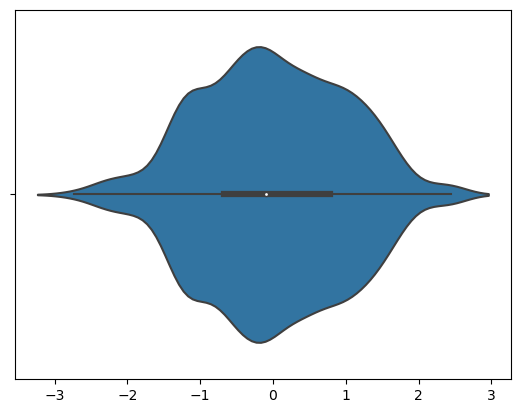

In [8]:
mean_train = X_train.mean(axis=0)
std_train = X_train.std(axis=0)

mean_y = y_train.mean(axis=0)
std_y = y_train.std(axis=0)

# Standardize the training data
X_train_scaled = (X_train - mean_train) / std_train

# Standardize the test data using the mean and 
#std from the training set to avoid data leakage
X_test_scaled = (X_test - mean_train) / std_train

# Check the mean and standard deviation of the scaled training data
print("Mean of scaled training data (should be approx 0):")
print(X_train_scaled.mean(axis=0))
print("\nStandard deviation of scaled training data (should be 1):")
print(X_train_scaled.std(axis=0))


# Create violin plot
sns.violinplot(x=X_train_scaled[:, 0])
plt.show()

In [9]:
# We see that the data has approximatly a normal distribution 
#and the mean is approximatly zero and all SD are 1

## Part IV: Training and evaluation with different dataset sizes and training times

Often, a larger dataset size will yield better model performance. (As we will learn later, this usually prevents overfitting and increases the generalization capability of the trained model.)
However, collecting data is usually rather expensive.

In this part of the exercise, you will investigate

- how the model performance changes with varying dataset size
- how the model performance changes with varying numbers of epochs/iterations of the optimizer/solver (increasing training time).

For this task (Part IV), use the `Adaline`, `Perceptron`, and `LogisticRegression` classifier from the `mlxtend` library. All use the gradient descent (GD) algorithm for training.

__Important__: Use a learning rate of `1e-4` (`0.0001`) for all classifiers, and use the argument `minibatches=1` when initializing `Adaline` and `LogisticRegression` classifier (this will make sure it uses GD). For all three classifiers, pass `random_seed=42` when initializing the classifier to ensure reproducibility of the results.

### Model training

Train the model models using progressively larger subsets of your dataset, specifically: first 50 rows, first 100 rows, first 150 rows, ..., first 650 rows, first 700 rows (in total $14$ different variants).

For each number of rows train the model with progressively larger number of epochs: 2, 7, 12, 17, ..., 87, 92, 97 (in total $20$ different model variants).

The resulting $14 \times 20 = 280$ models obtained from the different combinations of subsets and number of epochs. An output of the training process could look like this:

```
Model (1) Train a model with first 50 rows of data for 2 epochs
Model (2) Train a model with first 50 rows of data for 7 epochs
Model (3) Train a model with first 50 rows of data for 12 epochs
...
Model (21) Train a model with first 100 rows of data for 2 epochs
Model (22) Train a model with first 100 rows of data for 7 epochs
...
Model (279) Train a model with first 700 rows of data for 92 epochs
Model (280) Train a model with first 700 rows of data for 97 epochs
```

### Model evaluation

For each of the $280$ models, calculate the __accuracy on the test set__ (do __not__ use the score method but compute accuracy yourself).
Store the results in the provided 2D numpy array (it has $14$ rows and $20$ columns).
The rows of the array correspond to the different dataset sizes, and the columns correspond to the different numbers of epochs.

### Tasks
1. Train the $280$ Adaline classifiers as mentioned above and calculate the accuracy for each of the $280$ variants.
2. Generalize your code so that is doing the same procedure for all three classifiers: `Perceptron`, `Adaline`, and `LogisticRegression` after each other. Store the result for all classifiers. You can for example use an array of shape $3\times14\times20$ to store the accuracies of the three classifiers.

Note that executing the cells will take some time (but on most systems it should not be more than 5 minutes).

In [10]:
# Train and evaluate all model variants
# Insert your code below
# ======================

# Initialize variables for the training process
row_sizes = range(50, 701, 50)  # Dataset sizes from 50 to 700 inclusive
epoch_sizes = range(2, 98, 5)   # Epochs from 2 to 97 inclusive

# Create an array to store the accuracies for all classifiers
# Shape: 3 classifiers x 14 dataset sizes x 20 epoch sizes
accuracies = np.zeros((3, len(row_sizes), len(epoch_sizes)))

# Define the classifiers with a learning rate of 1e-4 and random_seed=42
classifiers = [
    Adaline,
    Perceptron,
    LogisticRegression
]

# Function to compute accuracy
def compute_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

# Train classifiers and record accuracies
for classifier_idx, classifier in enumerate(classifiers):
    for row_size_idx, row_size in enumerate(row_sizes):
        for epoch_idx, epochs in enumerate(epoch_sizes):
            cl = classifier(eta=0.0001, random_seed=42, epochs=epochs)
            
            # Slice the dataset to the current size
            X_subset = X_train_scaled[:row_size]
            y_subset = y_train[:row_size]
            # Train the classifier
            cl.fit(X_subset, y_subset)
            
            # Predict on the test set
            predictions = cl.predict(X_test_scaled)
            
            # Calculate accuracy
            accuracy = compute_accuracy(y_test, predictions)
            
            # Store the accuracy
            accuracies[classifier_idx, row_size_idx, epoch_idx] = accuracy

            # Output the training process
            model_num = classifier_idx \
            * (len(row_sizes) * len(epoch_sizes)) \
            + row_size_idx * len(epoch_sizes) + epoch_idx + 1
            print(f"Model ({model_num}) - "\
                f"{classifier.__class__.__name__}:")
            print(f"Train a model with first {row_size}"\
                  f"rows of data for {epochs} epochs")
            print(f"Accuracy: {accuracy:.2f}")

Model (1) - type:
Train a model with first 50rows of data for 2 epochs
Accuracy: 0.87
Model (2) - type:
Train a model with first 50rows of data for 7 epochs
Accuracy: 0.87
Model (3) - type:
Train a model with first 50rows of data for 12 epochs
Accuracy: 0.87
Model (4) - type:
Train a model with first 50rows of data for 17 epochs
Accuracy: 0.87
Model (5) - type:
Train a model with first 50rows of data for 22 epochs
Accuracy: 0.87
Model (6) - type:
Train a model with first 50rows of data for 27 epochs
Accuracy: 0.87
Model (7) - type:
Train a model with first 50rows of data for 32 epochs
Accuracy: 0.87
Model (8) - type:
Train a model with first 50rows of data for 37 epochs
Accuracy: 0.87
Model (9) - type:
Train a model with first 50rows of data for 42 epochs
Accuracy: 0.87
Model (10) - type:
Train a model with first 50rows of data for 47 epochs
Accuracy: 0.87
Model (11) - type:
Train a model with first 50rows of data for 52 epochs
Accuracy: 0.87
Model (12) - type:
Train a model with first

Model (291) - type:
Train a model with first 50rows of data for 52 epochs
Accuracy: 0.89
Model (292) - type:
Train a model with first 50rows of data for 57 epochs
Accuracy: 0.89
Model (293) - type:
Train a model with first 50rows of data for 62 epochs
Accuracy: 0.87
Model (294) - type:
Train a model with first 50rows of data for 67 epochs
Accuracy: 0.89
Model (295) - type:
Train a model with first 50rows of data for 72 epochs
Accuracy: 0.89
Model (296) - type:
Train a model with first 50rows of data for 77 epochs
Accuracy: 0.87
Model (297) - type:
Train a model with first 50rows of data for 82 epochs
Accuracy: 0.88
Model (298) - type:
Train a model with first 50rows of data for 87 epochs
Accuracy: 0.85
Model (299) - type:
Train a model with first 50rows of data for 92 epochs
Accuracy: 0.89
Model (300) - type:
Train a model with first 50rows of data for 97 epochs
Accuracy: 0.89
Model (301) - type:
Train a model with first 100rows of data for 2 epochs
Accuracy: 0.83
Model (302) - type:
T

Model (386) - type:
Train a model with first 300rows of data for 27 epochs
Accuracy: 0.86
Model (387) - type:
Train a model with first 300rows of data for 32 epochs
Accuracy: 0.89
Model (388) - type:
Train a model with first 300rows of data for 37 epochs
Accuracy: 0.79
Model (389) - type:
Train a model with first 300rows of data for 42 epochs
Accuracy: 0.89
Model (390) - type:
Train a model with first 300rows of data for 47 epochs
Accuracy: 0.84
Model (391) - type:
Train a model with first 300rows of data for 52 epochs
Accuracy: 0.61
Model (392) - type:
Train a model with first 300rows of data for 57 epochs
Accuracy: 0.88
Model (393) - type:
Train a model with first 300rows of data for 62 epochs
Accuracy: 0.85
Model (394) - type:
Train a model with first 300rows of data for 67 epochs
Accuracy: 0.87
Model (395) - type:
Train a model with first 300rows of data for 72 epochs
Accuracy: 0.88
Model (396) - type:
Train a model with first 300rows of data for 77 epochs
Accuracy: 0.88
Model (397

Model (478) - type:
Train a model with first 500rows of data for 87 epochs
Accuracy: 0.82
Model (479) - type:
Train a model with first 500rows of data for 92 epochs
Accuracy: 0.89
Model (480) - type:
Train a model with first 500rows of data for 97 epochs
Accuracy: 0.88
Model (481) - type:
Train a model with first 550rows of data for 2 epochs
Accuracy: 0.84
Model (482) - type:
Train a model with first 550rows of data for 7 epochs
Accuracy: 0.89
Model (483) - type:
Train a model with first 550rows of data for 12 epochs
Accuracy: 0.91
Model (484) - type:
Train a model with first 550rows of data for 17 epochs
Accuracy: 0.80
Model (485) - type:
Train a model with first 550rows of data for 22 epochs
Accuracy: 0.77
Model (486) - type:
Train a model with first 550rows of data for 27 epochs
Accuracy: 0.89
Model (487) - type:
Train a model with first 550rows of data for 32 epochs
Accuracy: 0.88
Model (488) - type:
Train a model with first 550rows of data for 37 epochs
Accuracy: 0.88
Model (489) 

Model (674) - type:
Train a model with first 300rows of data for 67 epochs
Accuracy: 0.87
Model (675) - type:
Train a model with first 300rows of data for 72 epochs
Accuracy: 0.87
Model (676) - type:
Train a model with first 300rows of data for 77 epochs
Accuracy: 0.87
Model (677) - type:
Train a model with first 300rows of data for 82 epochs
Accuracy: 0.87
Model (678) - type:
Train a model with first 300rows of data for 87 epochs
Accuracy: 0.88
Model (679) - type:
Train a model with first 300rows of data for 92 epochs
Accuracy: 0.88
Model (680) - type:
Train a model with first 300rows of data for 97 epochs
Accuracy: 0.88
Model (681) - type:
Train a model with first 350rows of data for 2 epochs
Accuracy: 0.85
Model (682) - type:
Train a model with first 350rows of data for 7 epochs
Accuracy: 0.86
Model (683) - type:
Train a model with first 350rows of data for 12 epochs
Accuracy: 0.87
Model (684) - type:
Train a model with first 350rows of data for 17 epochs
Accuracy: 0.86
Model (685) 

Model (828) - type:
Train a model with first 700rows of data for 37 epochs
Accuracy: 0.87
Model (829) - type:
Train a model with first 700rows of data for 42 epochs
Accuracy: 0.87
Model (830) - type:
Train a model with first 700rows of data for 47 epochs
Accuracy: 0.87
Model (831) - type:
Train a model with first 700rows of data for 52 epochs
Accuracy: 0.87
Model (832) - type:
Train a model with first 700rows of data for 57 epochs
Accuracy: 0.88
Model (833) - type:
Train a model with first 700rows of data for 62 epochs
Accuracy: 0.88
Model (834) - type:
Train a model with first 700rows of data for 67 epochs
Accuracy: 0.88
Model (835) - type:
Train a model with first 700rows of data for 72 epochs
Accuracy: 0.88
Model (836) - type:
Train a model with first 700rows of data for 77 epochs
Accuracy: 0.88
Model (837) - type:
Train a model with first 700rows of data for 82 epochs
Accuracy: 0.88
Model (838) - type:
Train a model with first 700rows of data for 87 epochs
Accuracy: 0.88
Model (839

### Performance visualization

Plot the performance measure for all classifiers (accuracy on the test set; use the result array from above) of all the $280$ variants for each classifier in a total of three heatmaps using, for example `seaborn` or `matplotlib` directly.

The color should represent the accuracy on the test set, and the x and y axes should represent the number of epochs and the dataset size, respectively.
Which one is x and which one is y is up to you to decide. Look in the example output at the top of the assignment for inspiration for how the plot could look like and how it could be labeled nicely. (But use the correct numbers corresponding to your dataset sizes and number of epochs.)

Adaline


Text(50.722222222222214, 0.5, 'Row size')

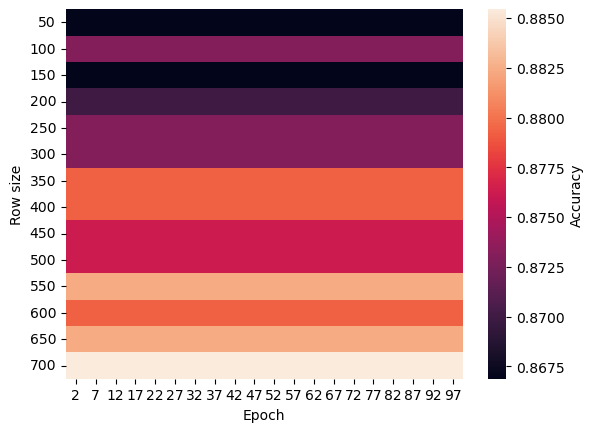

In [11]:
# Insert your code below
# ======================
print("Adaline")
plt_df = pd.DataFrame(accuracies[0, :],\
                      columns=epoch_sizes,\
                      index=row_sizes)
sns.heatmap(plt_df, cbar_kws={"label": "Accuracy"})
plt.xlabel("Epoch")
plt.ylabel("Row size")

Perceptron


Text(50.722222222222214, 0.5, 'Row size')

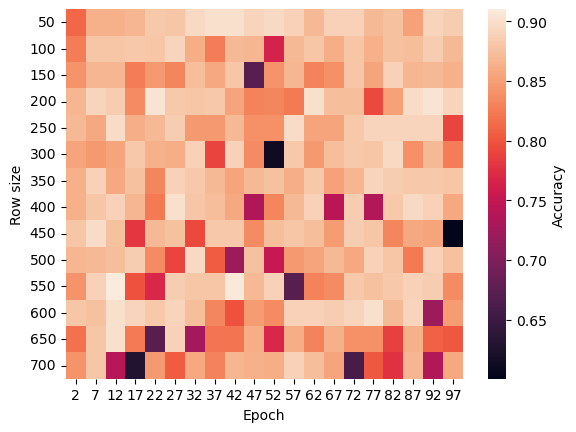

In [12]:
# Insert your code below
# ======================
print("Perceptron")
plt_df = pd.DataFrame(accuracies[1, :], \
                      columns=epoch_sizes,\
                      index=row_sizes)
sns.heatmap(plt_df, cbar_kws={"label": "Accuracy"})
plt.xlabel("Epoch")
plt.ylabel("Row size")

LogisticRegression


Text(50.722222222222214, 0.5, 'Row size')

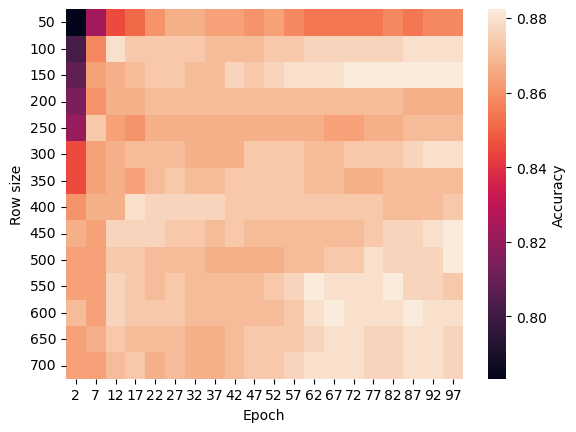

In [13]:
# Insert your code below
# ======================
print("LogisticRegression")
plt_df = pd.DataFrame(accuracies[2, :], \
                      columns=epoch_sizes, \
                      index=row_sizes)
sns.heatmap(plt_df, cbar_kws={"label": "Accuracy"})
plt.xlabel("Epoch")
plt.ylabel("Row size")

# Part V: Some more plotting

For the following cell to execute you need to have the variable `X_test_scaled` with all samples of the test set and the variable `y_test` with the corresponding labels.
Complete at least up until Part III. Executing the cell will plot something.

1. Add code comments explaining what the lines are doing
2. What is the purpose of the plot?
3. Describe all components of the subplot and then comment in general on the entire plot. What does it show? What does it not show?

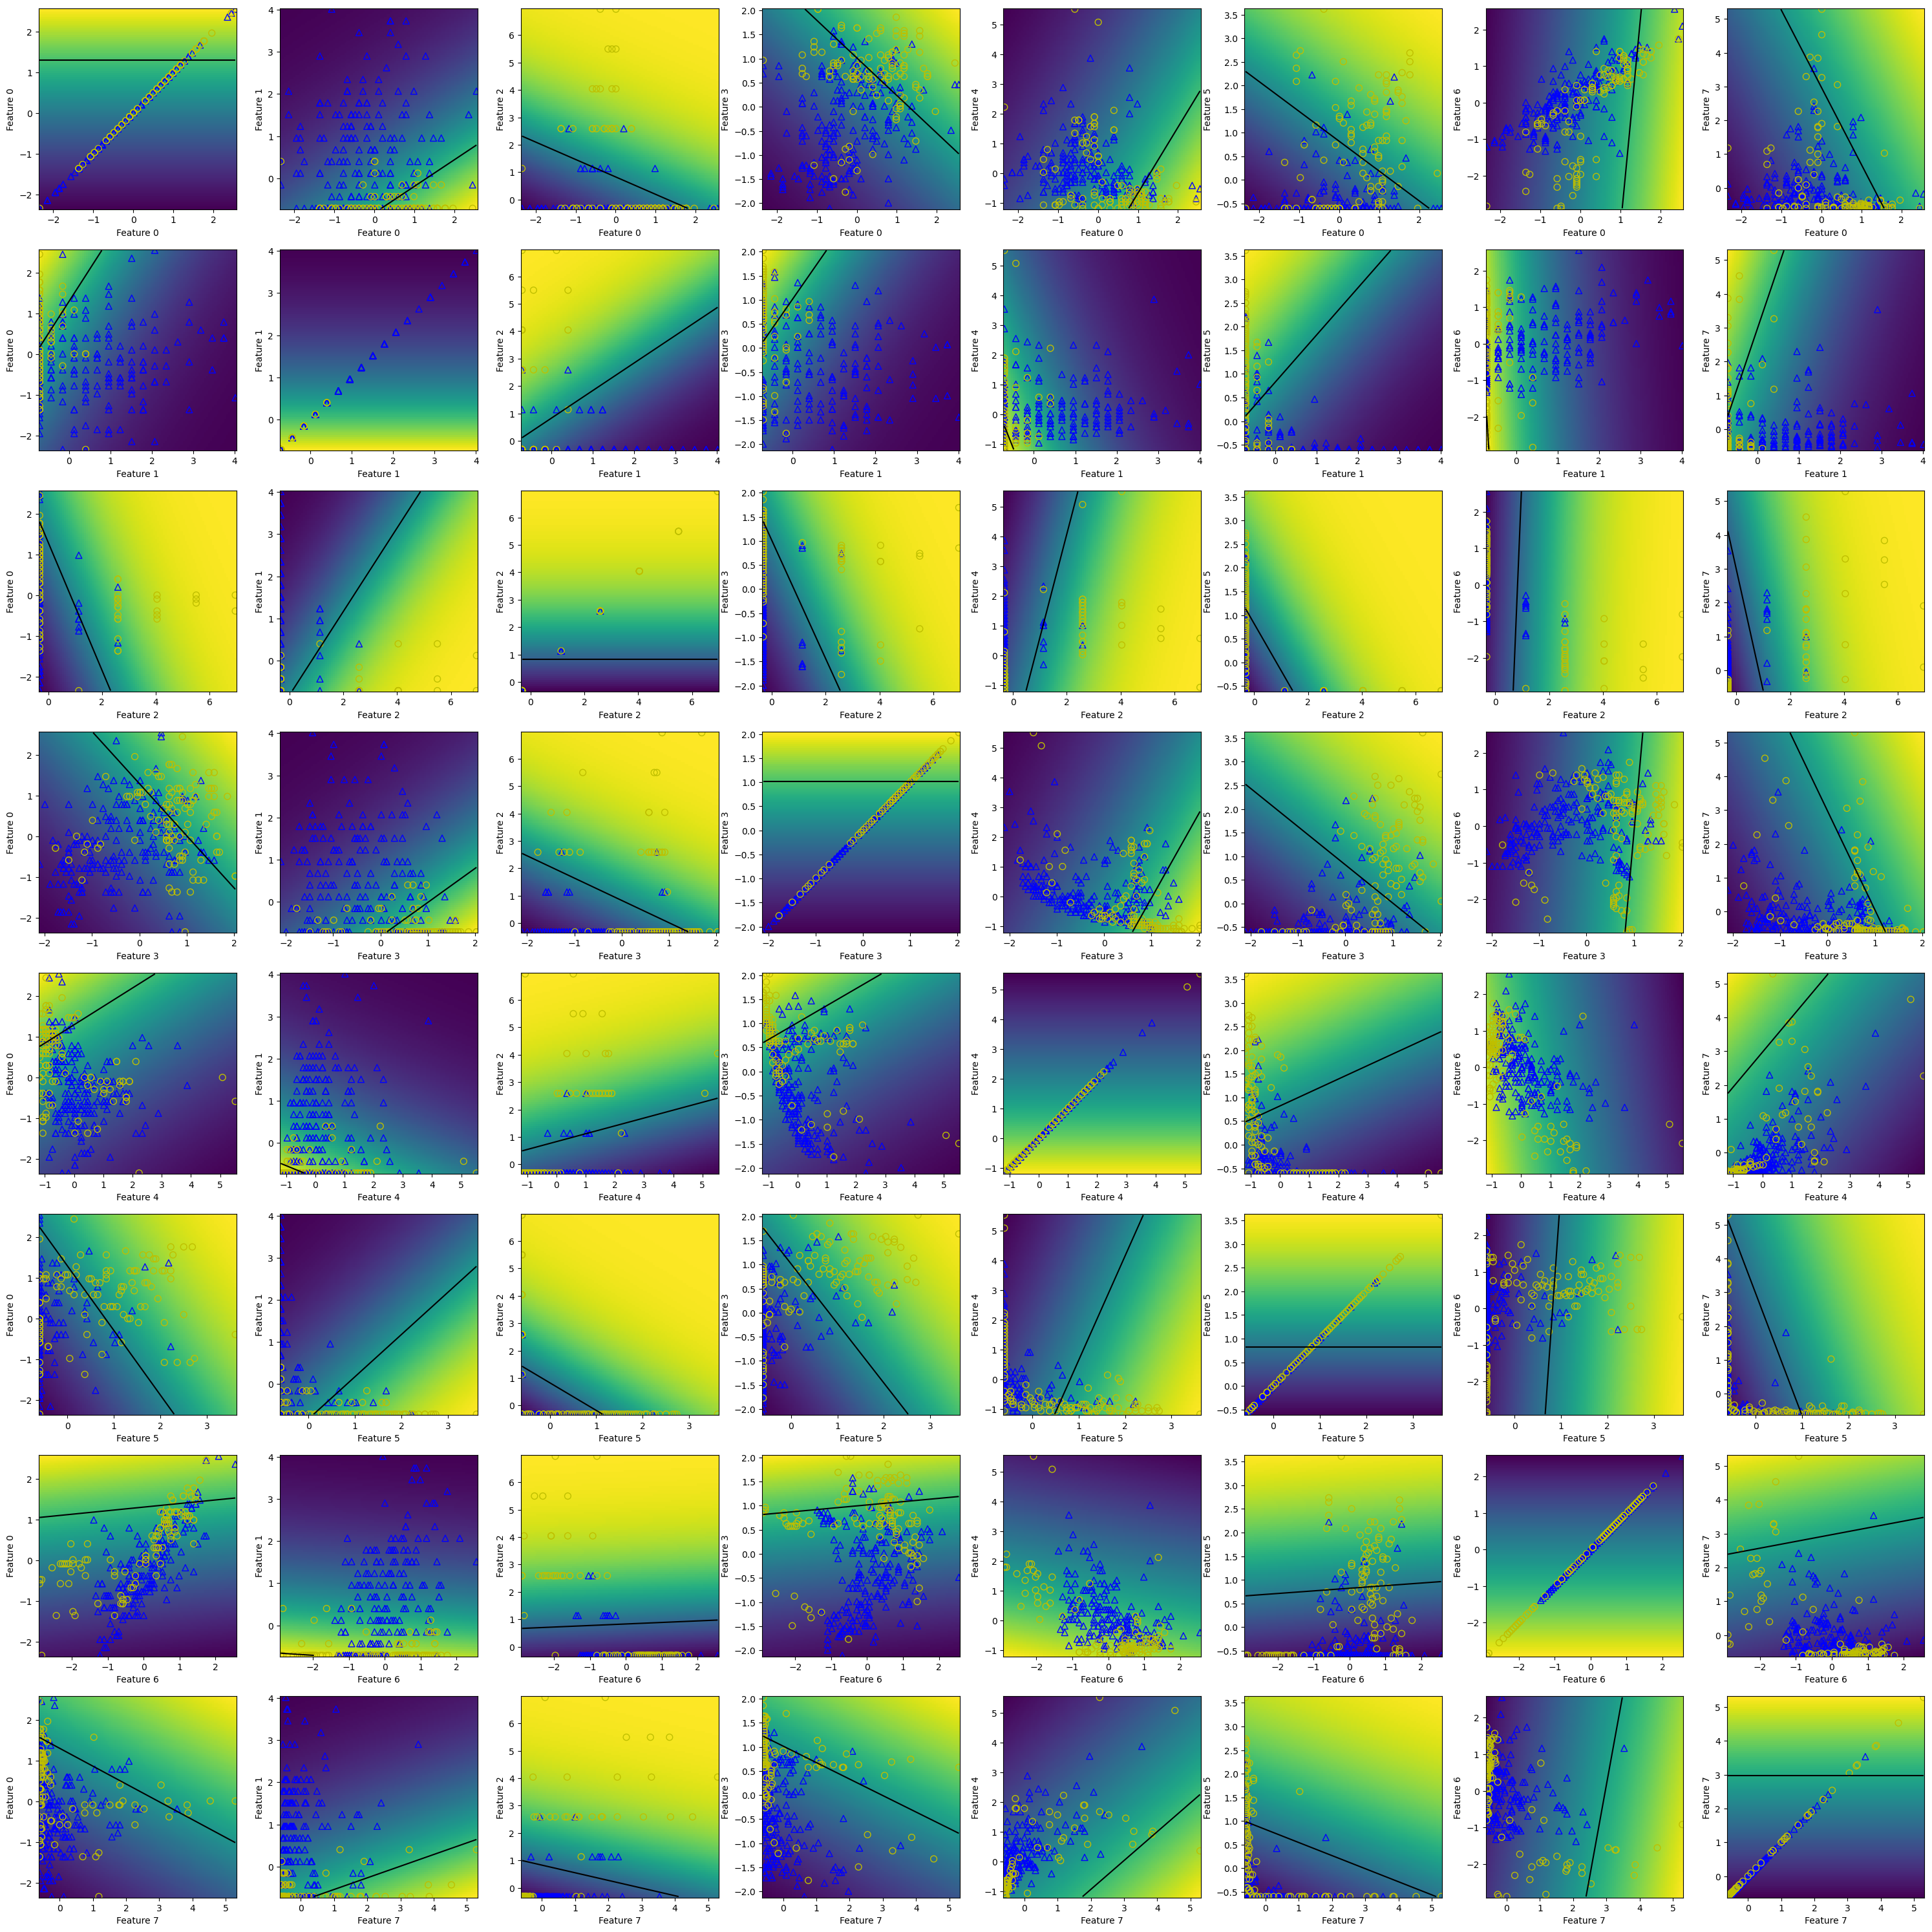

In [14]:
# Train and a logistic regression model with 300 epochs and learning rate 0.0001
clf = LogisticRegression(eta = 0.0001,\
                         epochs = 300, minibatches=1, random_seed=42) 
#This line intialize  the logistic regression classifier
#with 0.0001 learning rate for total of 300 training epochs. 
#the mini data set indicates the entire dataset for each gradient update


#Training the model
clf.fit(X_test_scaled, y_test) 
# this line the classifier to the scaled test dataset with the corresponding labels 

#Getting a 8x8 grid for plots
fig, axes = plt.subplots(8, 8, figsize=(30, 30))

#Looping over the features
for i in range(0, 8):
    #Looping over the features
    for j in range(0, 8):
        feature_1 = i
        feature_2 = j
        ax = axes[i, j]
        #For loops iterate over pairs of features for a total of 64 
        #combinations to create plots for each pair.
        # for each subplot in the grid, it select two features 
        #to compare and sets ax to the currunt subplot axes

        #setting the name of the axis
        ax.set_xlabel(f"Feature {feature_1}")
        ax.set_ylabel(f"Feature {feature_2}")
        #Thes sets the x and y labels of the current subplot

        #computes the minimum and maximum values for each feature
        mins = X_test_scaled.min(axis=0)
        maxs = X_test_scaled.max(axis=0)

        #Generates a grid of points to plot the decision boundaries, 
        #using 100 points between the min and max of each feature.
        x0 = np.linspace(mins[feature_1], maxs[feature_1], 100)
        x1 = np.linspace(mins[feature_2], maxs[feature_2], 100)
        
        #Prepares a 2D array with all combinations of 
        #feature values from the meshgrid
        X0, X1 = np.meshgrid(x0, x1)
        X_two_features = np.c_[X0.ravel(), X1.ravel()]
        X_plot = np.zeros(shape=(X_two_features.shape[0],\
                                 X_test_scaled.shape[1]))
        
        #Copies the grid values into the corresponding columns 
        #of the dataset array for prediction
        X_plot[:, feature_1] = X_two_features[:, 0]
        X_plot[:, feature_2] = X_two_features[:, 1]
        
        #Predicts class probabilities for each point on the grid
        #and reshapes the output to fit the meshgrid dimensions.
        y_pred = clf.predict_proba(X_plot)
        Z = y_pred.reshape(X0.shape)
        
        #Plots the test data points onto the corresponding subplot,
        #using different colors and markers for each class
        ax.pcolor(X0, X1, Z)
        ax.contour(X0, X1, Z, levels=[0.5], colors='k')
        ax.scatter(X_test_scaled[y_test == 0, feature_1],\
                   X_test_scaled[y_test == 0, feature_2],\
                   color="b", marker="^", s=50, facecolors="none")
        
        ax.scatter(X_test_scaled[y_test == 1, feature_1],\
                   X_test_scaled[y_test == 1, feature_2],\
                   color="y", marker="o", s=50, facecolors="none")
        
fig.tight_layout()
plt.show()
#Adjusts the layout to prevent subplot elements from 
#overlapping and displays the complete figure.

#the purpose of the plot is to see how features are
#related to each others, the plots shows that none of the
#features are linearly separable

## Part VI: Additional discussion

### Part I:
1. What kind of plots did you use to visualize the raw data, and why did you choose these types of plots?

In the begnning I used histograms to see the distribution of the plots and know if they need to be scaled or not.
After that I used the pairplot to see if the data is linearly seperable or not. Then a viloin plot was used
to see the data range and the distribution of it. Heatmap was used to visualize the accuracy of the different
models trained with different number of epochs and rows. In the end scatter plots were used to see how variables were
related to each other.

### Part II:
1. What happens if we don't shuffle the training data before training the classifiers like in Part IV?

Not shuffling the training data will result poor generalization, because the first rows of the data
migh be strongly correlated, leading to a model that is skewed to some feature more then others.

2. How could you do the same train/test split (Point 1.-4.) using scikit-learn?

```python
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
```

### Part IV:
1. How does increasing the dataset size affect the performance of the logistic regression model? Provide a summary of your findings.

From the heatmap we see that upto 450 training data, the model was consistently getting better. After that
overlearning started to happen leading to no better results.

2. Describe the relationship between the number of epochs and model accuracy

Looking at the heatmap, see that the number of epochs plays no role for the Adalin classifier, for the
perceptron it lead to worse result, this might be becuase of the overlearning. For the logistic regression
we see that it made a big difference when the number of data was little, but when the number of data increased,
it started playing a smaller role, but it increased the accuracy.


3. Which classifier is much slower to train and why do you think that is?

Logistic classifier must be the slowest due to how the activation and gradient calculated.

4. One classifier shows strong fluctuations in accuracy for different dataset sizes and number of epochs. Which one is it and why do you think this happens?

From the heatmap, we see that it is the perceptron, this can be a result of overlearning or badly initial weights.